In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set(font_scale=1.3)
pd.set_option('display.max_rows',None)
pd.set_option('display.max_column',None)

In [2]:
data = pd.read_csv("top_10000_1950-now.csv")
data.head(2)

,Track URI,Track Name,Artist URI(s),Artist Name(s),Album URI,Album Name,Album Artist URI(s),Album Artist Name(s),Album Release Date,Album Image URL,Disc Number,Track Number,Track Duration (ms),Track Preview URL,Explicit,Popularity,ISRC,Added By,Added At,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Genres,Label,Copyrights
0,spotify:track:0vNPJrUrBnMFdCs8b2MTNG,Fader,spotify:artist:4W48hZAnAHVOC2c8WH8pcq,The Temper Trap,spotify:album:0V59MMtgoruvEqMv18KAOH,Conditions (Tour Edition),spotify:artist:4W48hZAnAHVOC2c8WH8pcq,The Temper Trap,2009,https://i.scdn.co/image/ab67616d0000b273f86ae8...,1,6,192373,https://p.scdn.co/mp3-preview/14264bd1501d2723...,False,0,GBZUZ0900014,spotify:user:bradnumber1,2021-08-08T09:26:31Z,"indietronica,modern rock,shimmer pop",0.532,0.760,11.0,-7.123,0.0,0.0353,0.000101,0.69,0.0752,0.158,134.974,4.0,NaN,Liberation Records,"C 2010 Liberation Music, P 2010 Liberation Music"
1,spotify:track:0NpvdCO506uO58D4AbKzki,Sherry,spotify:artist:6mcrZQmgzFGRWf7C0SObou,Frankie Valli & The Four Seasons,spotify:album:0NUEQILaBzavnzcMEs4buZ,The Very Best of Frankie Valli & The 4 Seasons,spotify:artist:6mcrZQmgzFGRWf7C0SObou,Frankie Valli & The Four Seasons,2003-01-14,https://i.scdn.co/image/ab67616d0000b273b96c21...,1,1,152160,https://p.scdn.co/mp3-preview/e3f765262ebc349e...,False,54,USRH10175197,spotify:user:bradnumber1,2021-08-08T09:26:31Z,"adult standards,bubblegum pop,doo-wop,lounge,n...",0.703,0.478,7.0,-8.062,1.0,0.0441,0.626000,0.00,0.1130,0.734,117.562,4.0,NaN,Rhino,C © 2004 Bob Gaudio & Frankie Valli d/b/a The ...


In [3]:
data.shape

(10000, 35)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Track URI             10000 non-null  object 
 1   Track Name            9998 non-null   object 
 2   Artist URI(s)         9998 non-null   object 
 3   Artist Name(s)        9998 non-null   object 
 4   Album URI             9998 non-null   object 
 5   Album Name            9998 non-null   object 
 6   Album Artist URI(s)   9998 non-null   object 
 7   Album Artist Name(s)  9998 non-null   object 
 8   Album Release Date    9998 non-null   object 
 9   Album Image URL       9996 non-null   object 
 10  Disc Number           10000 non-null  int64  
 11  Track Number          10000 non-null  int64  
 12  Track Duration (ms)   10000 non-null  int64  
 13  Track Preview URL     9937 non-null   object 
 14  Explicit              10000 non-null  bool   
 15  Popularity          

In [6]:
data.duplicated().sum()

47

In [7]:
data.drop_duplicates(inplace=True)

In [8]:
data.drop(["Track URI", "Artist URI(s)", "Album URI", "Album Artist URI(s)",
           "Album Image URL", "Added By", "Added At", "Explicit", "Album Genres",
           "ISRC", "Disc Number", "Track Preview URL", "Copyrights"], axis=1, inplace=True)

In [9]:
data.head(2)

,Track Name,Artist Name(s),Album Name,Album Artist Name(s),Album Release Date,Track Number,Track Duration (ms),Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Label
0,Fader,The Temper Trap,Conditions (Tour Edition),The Temper Trap,2009,6,192373,0,"indietronica,modern rock,shimmer pop",0.532,0.760,11.0,-7.123,0.0,0.0353,0.000101,0.69,0.0752,0.158,134.974,4.0,Liberation Records
1,Sherry,Frankie Valli & The Four Seasons,The Very Best of Frankie Valli & The 4 Seasons,Frankie Valli & The Four Seasons,2003-01-14,1,152160,54,"adult standards,bubblegum pop,doo-wop,lounge,n...",0.703,0.478,7.0,-8.062,1.0,0.0441,0.626000,0.00,0.1130,0.734,117.562,4.0,Rhino


In [10]:
data.shape

(9953, 22)

In [11]:
data.isna().sum()

Track Name                2
Artist Name(s)            2
Album Name                2
Album Artist Name(s)      2
Album Release Date        2
Track Number              0
Track Duration (ms)       0
Popularity                0
Artist Genres           551
Danceability              5
Energy                    5
Key                       5
Loudness                  5
Mode                      5
Speechiness               5
Acousticness              5
Instrumentalness          5
Liveness                  5
Valence                   5
Tempo                     5
Time Signature            5
Label                     7
dtype: int64

In [12]:
data.drop_duplicates(inplace=True)

In [13]:
data.shape

(9951, 22)

In [14]:
num_df = data.select_dtypes(include=['number'])
num_cols = num_df.columns
len(num_cols)

15

In [15]:
cat_df = data.select_dtypes(include=['object'])
cat_cols = num_df.columns
len(cat_cols)

15

In [16]:
df_describe = num_df.describe()
df_describe.loc['median'] = num_df.median()
df_describe.loc['mode'] = num_df.mode().iloc[0]
df_describe.loc['trim_mean'] = stats.trim_mean(num_df,proportiontocut=0.1)
df_describe.T

,count,mean,std,min,25%,50%,75%,max,median,mode,trim_mean
Track Number,9951.0,4.938599,5.467928,0.000000,1.00000,3.000000,7.000000,93.000,3.000000,1.0000,3.938073
Track Duration (ms),9951.0,224200.392121,54153.875861,0.000000,192106.00000,219428.000000,249799.500000,1561133.000,219428.000000,208106.0000,220775.141691
Popularity,9951.0,32.479952,27.501608,0.000000,0.00000,34.000000,57.000000,94.000,34.000000,0.0000,31.104384
Danceability,9946.0,0.608270,0.145758,0.000000,0.51525,0.618000,0.710000,0.988,0.618000,0.6710,NaN
Energy,9946.0,0.684127,0.191138,0.000020,0.56100,0.713000,0.836000,0.997,0.713000,0.7400,NaN
Key,9946.0,5.173638,3.584940,0.000000,2.00000,5.000000,8.000000,11.000,5.000000,0.0000,NaN
Loudness,9946.0,-7.247815,3.279408,-29.368000,-9.00400,-6.492000,-4.875250,2.769,-6.492000,-6.6840,NaN
Mode,9946.0,0.697969,0.459162,0.000000,0.00000,1.000000,1.000000,1.000,1.000000,1.0000,NaN
Speechiness,9946.0,0.065029,0.061101,0.000000,0.03310,0.042900,0.067600,0.711,0.042900,0.0305,NaN
Acousticness,9946.0,0.208331,0.249131,0.000003,0.01810,0.095300,0.317000,0.991,0.095300,0.1070,NaN


In [17]:
df_describe.T[['mean','trim_mean','median','mode']]

,mean,trim_mean,median,mode
Track Number,4.938599,3.938073,3.000000,1.0000
Track Duration (ms),224200.392121,220775.141691,219428.000000,208106.0000
Popularity,32.479952,31.104384,34.000000,0.0000
Danceability,0.608270,NaN,0.618000,0.6710
Energy,0.684127,NaN,0.713000,0.7400
Key,5.173638,NaN,5.000000,0.0000
Loudness,-7.247815,NaN,-6.492000,-6.6840
Mode,0.697969,NaN,1.000000,1.0000
Speechiness,0.065029,NaN,0.042900,0.0305
Acousticness,0.208331,NaN,0.095300,0.1070


In [18]:
def box_plot(df,nGraphShown,nGrapherRow):
    nunique = df.nunique()
    nRow,nCol = df.shape
    columnsName = list(df)
    nGraphRow = int((nCol + nGrapherRow - 1)/nGrapherRow)
    plt.figure(num=None, figsize=(6 * nGrapherRow, 8 * nGraphRow),dpi=80,facecolor='w',edgecolor='k')
    for i in range(min(nCol,nGraphShown)):
        plt.subplot(nGraphRow,nGrapherRow, i+1)
        column_df = df.iloc[:,1]
        column_df.plot.box()
        plt.xticks(rotation=90)
        plt.title(f'{columnsName[i]}(column{ i + 1})')
    plt.tight_layout(pad=1.0,w_pad=1.0,h_pad=1.0)
    plt.show()


In [21]:
def eda(start,end):
    num_df[num_cols[start:end]].hist(figsize=(12,8),layout=(2,4))
    box_plot(num_df[num_cols[start:end]],8,4)
    plt.show()
    print()
    print('Unique Values')
    for col in num_cols[start:end]:
        print(col,':',num_df[col].nunique())

In [22]:
num_df.shape

(9951, 15)

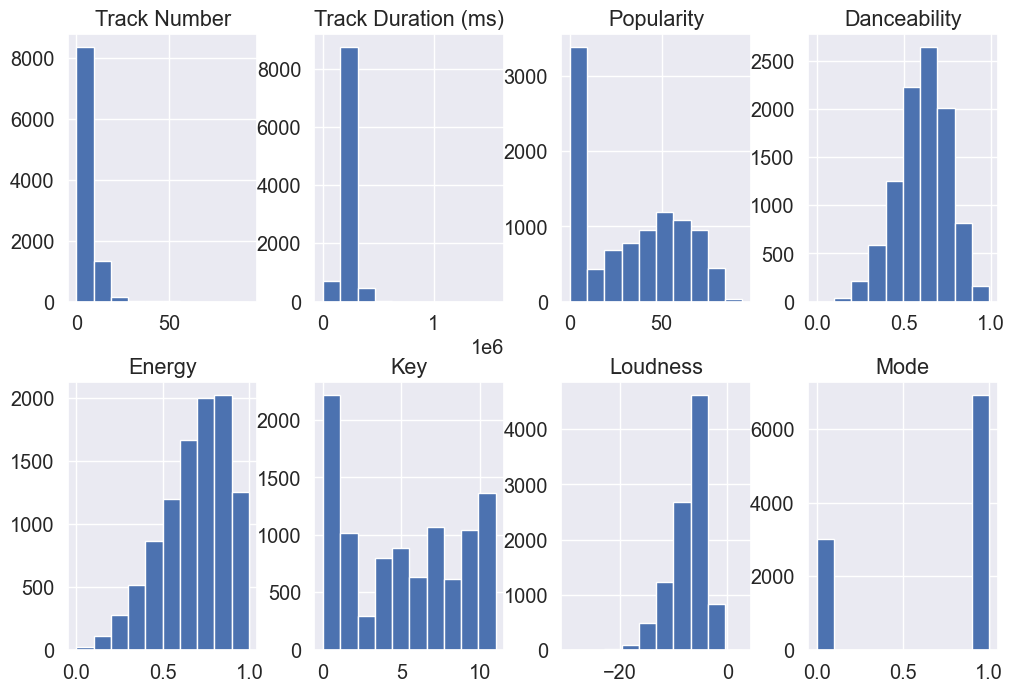

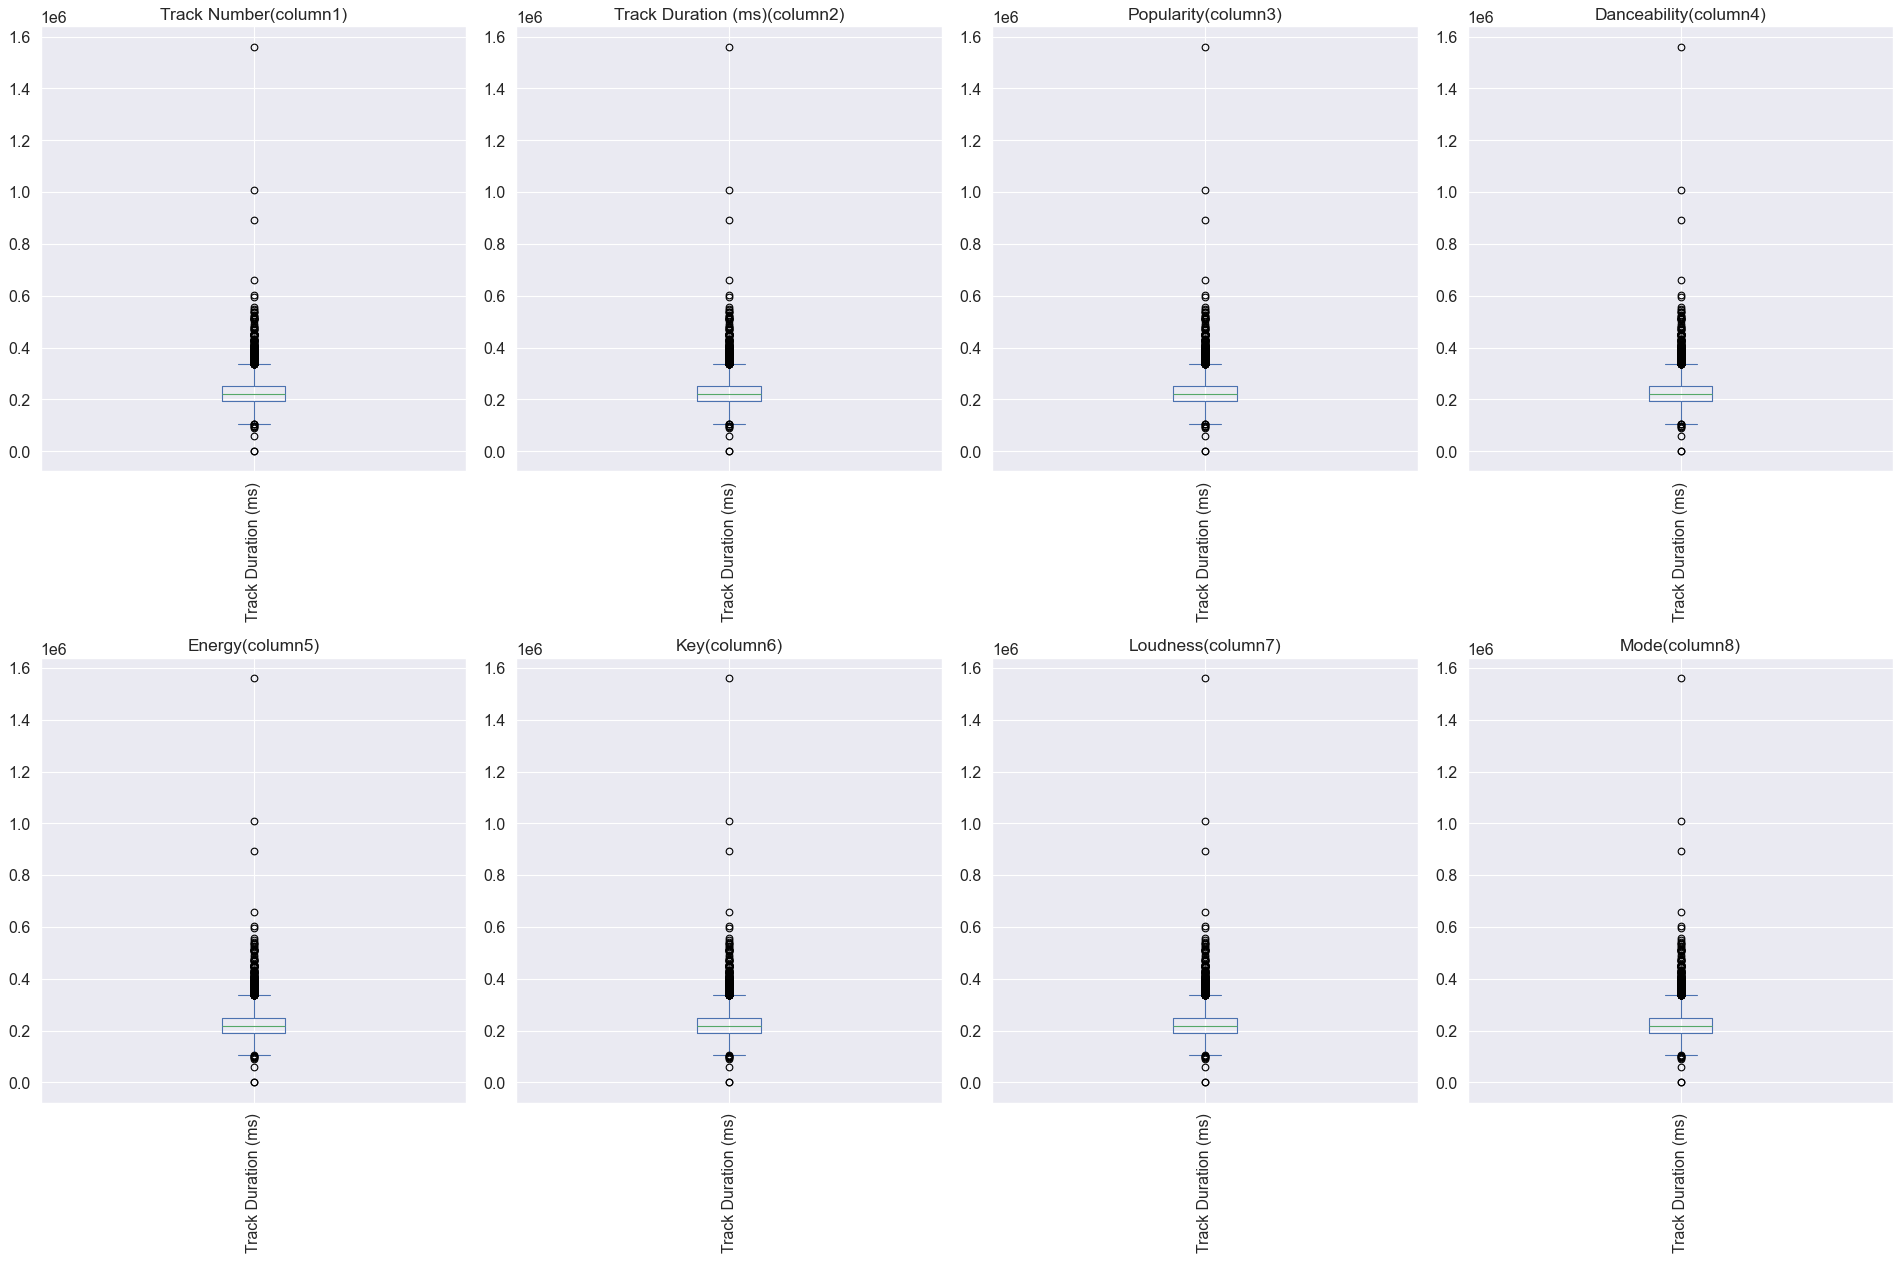


Unique Values
Track Number : 56
Track Duration (ms) : 7348
Popularity : 92
Danceability : 779
Energy : 874
Key : 12
Loudness : 6328
Mode : 2


In [23]:
eda(0,8)

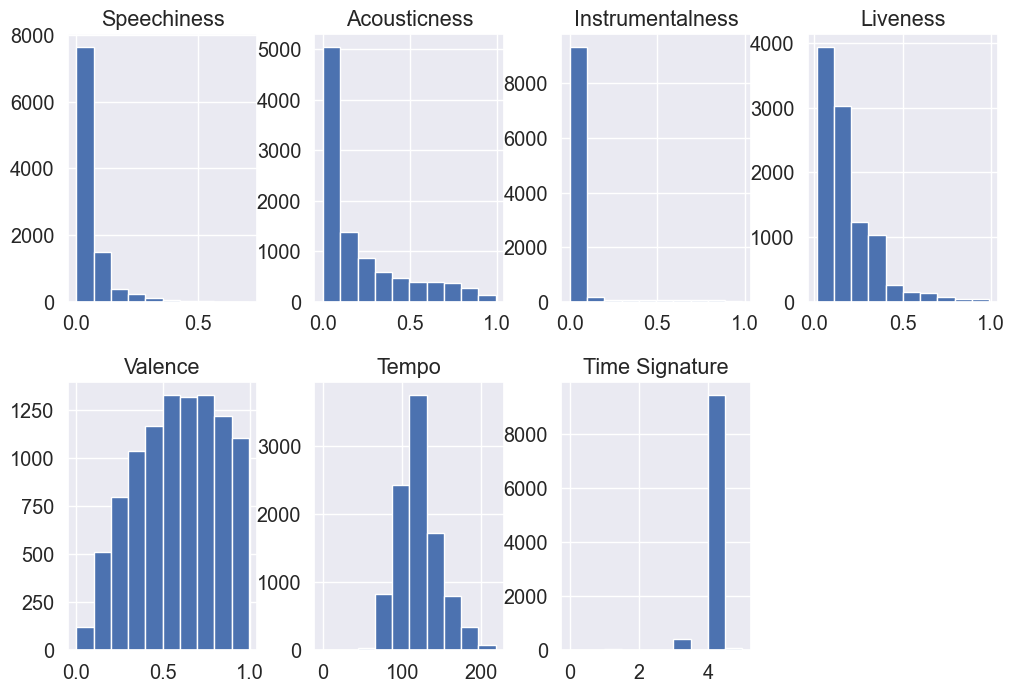

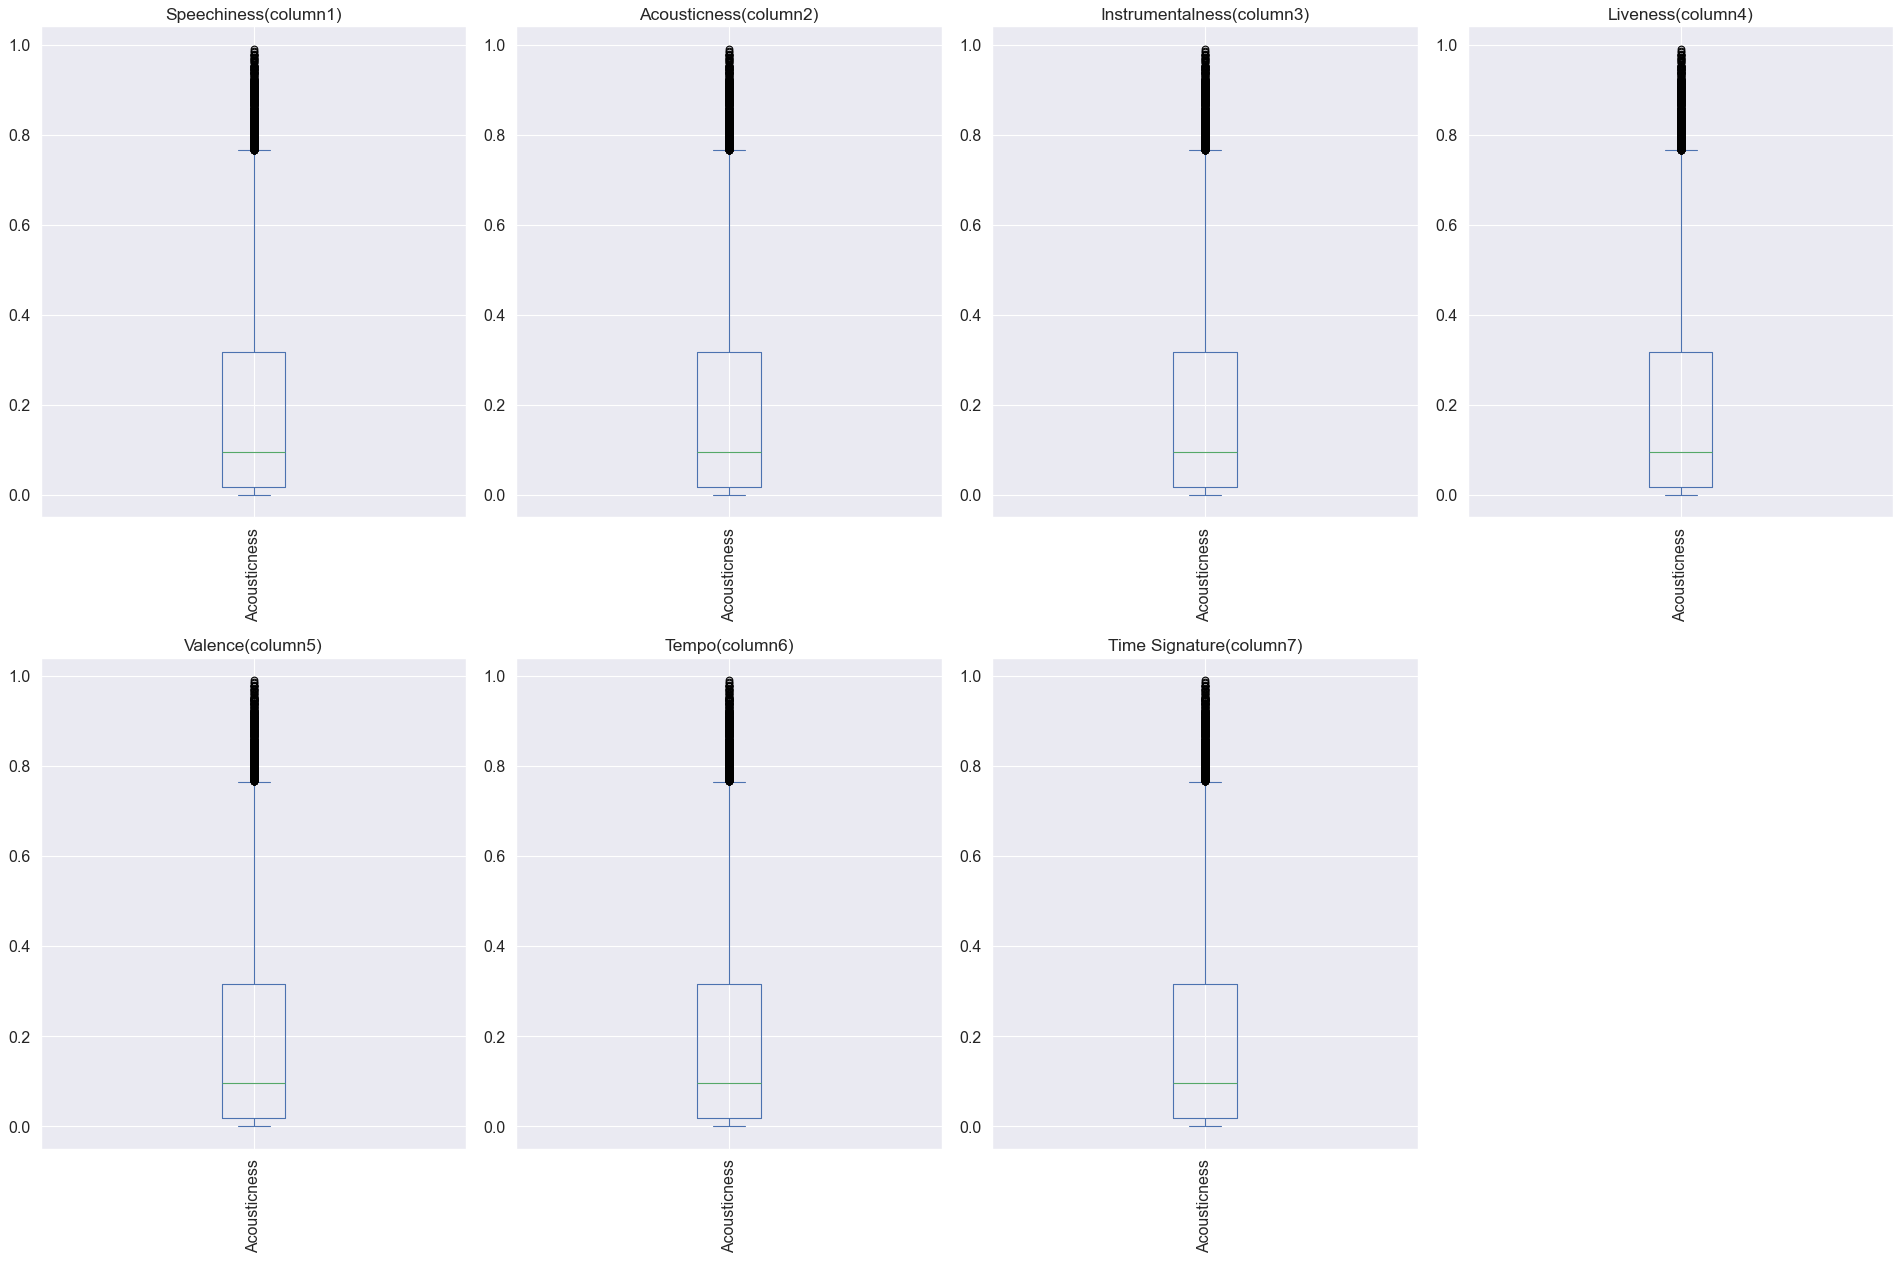


Unique Values
Speechiness : 1054
Acousticness : 2763
Instrumentalness : 3023
Liveness : 1357
Valence : 996
Tempo : 8609
Time Signature : 5


In [24]:
eda(8,16)

In [25]:
cat_df.head(3)

,Track Name,Artist Name(s),Album Name,Album Artist Name(s),Album Release Date,Artist Genres,Label
0,Fader,The Temper Trap,Conditions (Tour Edition),The Temper Trap,2009,"indietronica,modern rock,shimmer pop",Liberation Records
1,Sherry,Frankie Valli & The Four Seasons,The Very Best of Frankie Valli & The 4 Seasons,Frankie Valli & The Four Seasons,2003-01-14,"adult standards,bubblegum pop,doo-wop,lounge,n...",Rhino
2,I Took A Pill In Ibiza - Seeb Remix,"Mike Posner, Seeb","At Night, Alone.",Mike Posner,2016-05-06,"dance pop,pop,pop dance,pop rap,pop dance","Monster Mountain, LLC / Island"


In [26]:
cat_df.shape

(9951, 7)

In [28]:
cat_df.nunique()

Track Name              8287
Artist Name(s)          4155
Album Name              6650
Album Artist Name(s)    3312
Album Release Date      3372
Artist Genres           2834
Label                   1479
dtype: int64

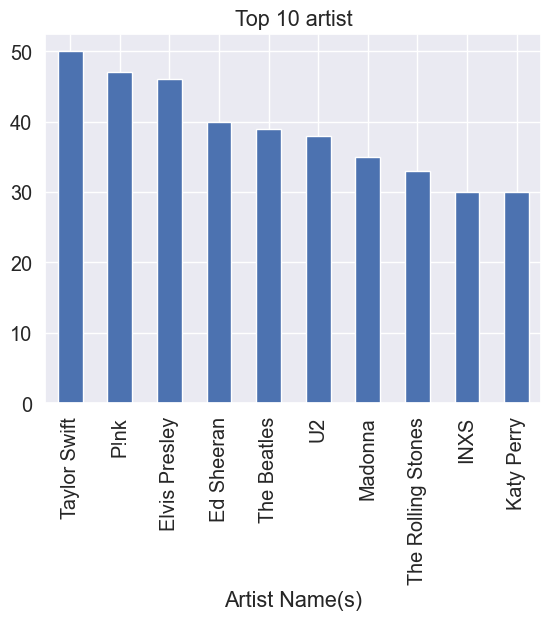

In [29]:
top10_artist = cat_df.groupby(by='Artist Name(s)')['Artist Name(s)'].count().sort_values(ascending=False)[:10]
top10_artist.plot(kind='bar')
plt.title('Top 10 artist')
plt.show()

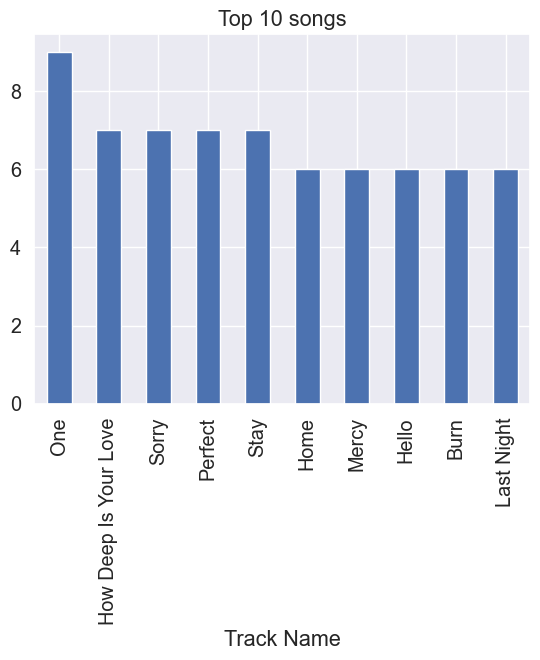

In [30]:
top10_artists = cat_df.groupby(by='Track Name')['Track Name'].count().sort_values(ascending=False)[:10]
top10_artists.plot(kind='bar')
plt.title('Top 10 songs')
plt.show()

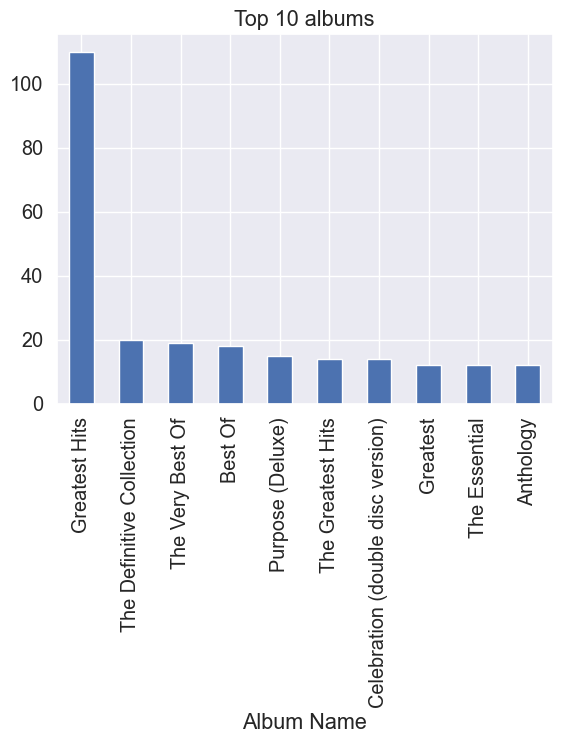

In [31]:
top10_artists = cat_df.groupby(by='Album Name')['Album Name'].count().sort_values(ascending=False)[:10]
top10_artists.plot(kind='bar')
plt.title('Top 10 albums')
plt.show()

In [32]:
data['Album Release Date'] = pd.to_datetime(data['Album Release Date'],errors='coerce')


In [34]:
data['ReleaseYear'] = data['Album Release Date'].dt.year

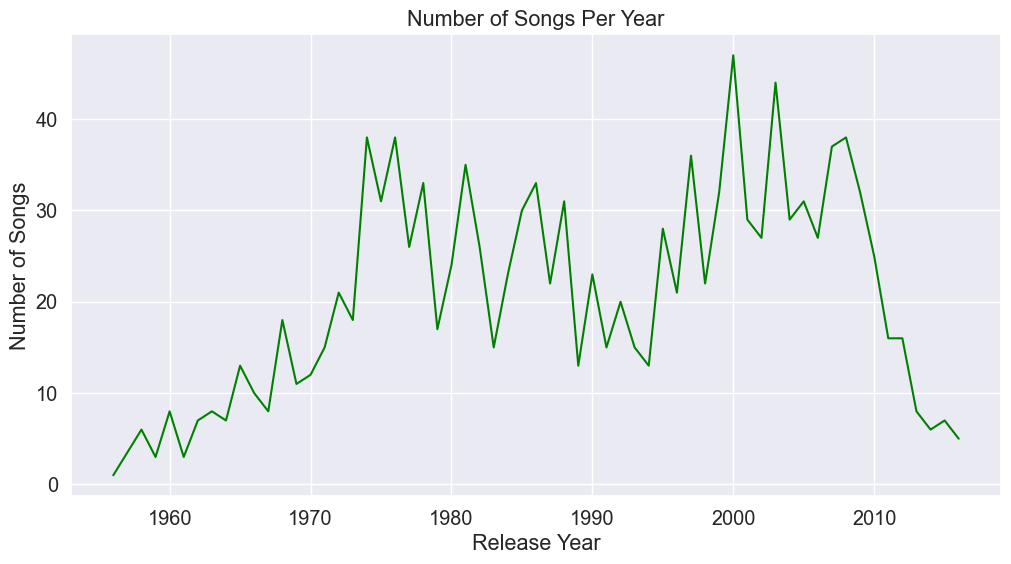

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Extract the 4-digit Year from 'Album Release Date'
data['ReleaseYear'] = (
    pd.to_datetime(data['Album Release Date'], errors='coerce')
    .dt.year.astype('Int64')
)

# 2. Count songs per year & clean up column names
songs_per_year = (
    data['ReleaseYear']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'Songs'})
    .sort_values(by='ReleaseYear')
)

# 3. Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=songs_per_year, x='ReleaseYear', y='Songs', color='green')
plt.title('Number of Songs Per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Songs')
plt.show()

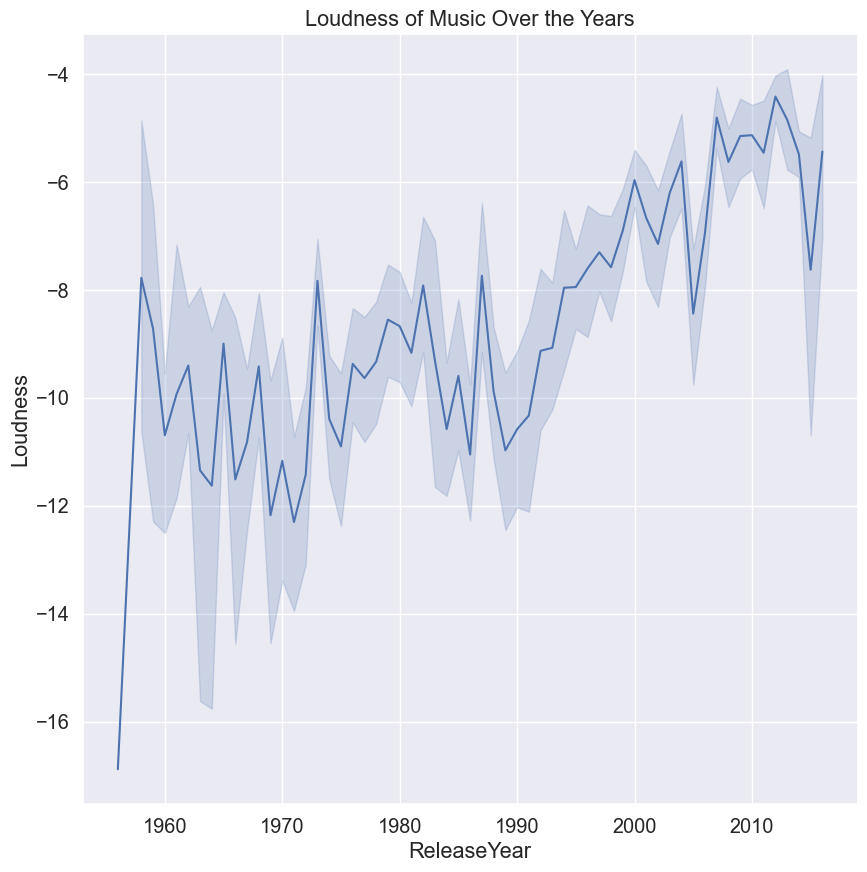

In [39]:
plt.figure(figsize=(10, 10))
sns.lineplot(x="ReleaseYear", y="Loudness", data=data)
plt.title("Loudness of Music Over the Years")
plt.show()

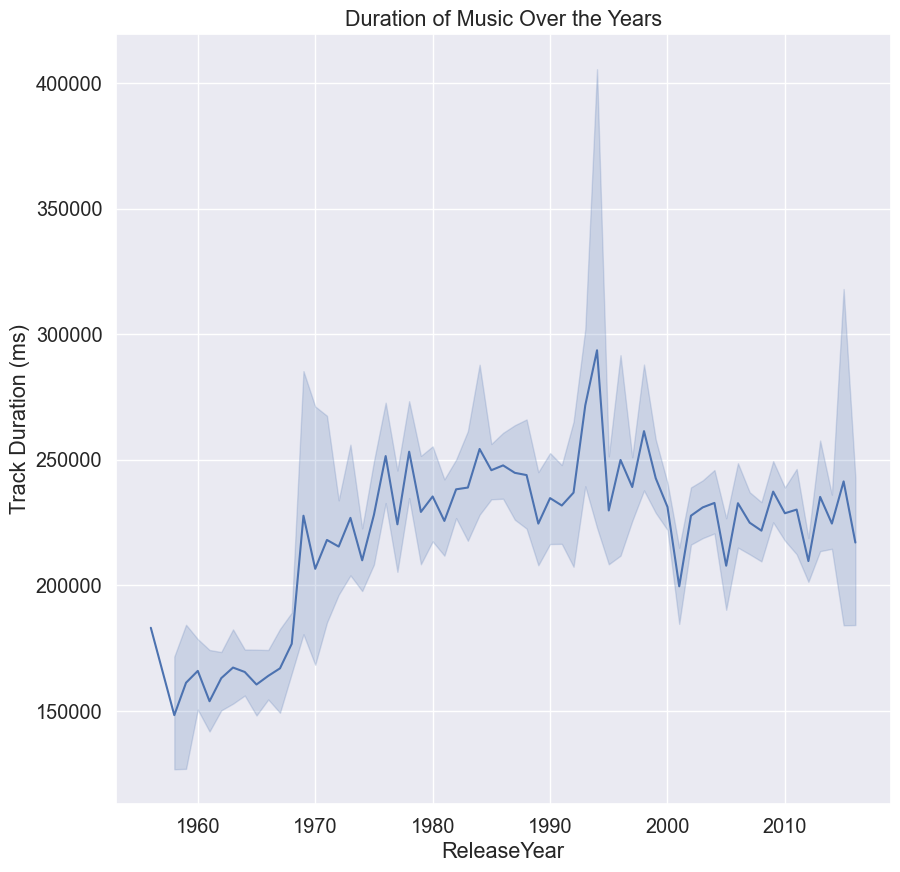

In [40]:
plt.figure(figsize=(10, 10))
sns.lineplot(x="ReleaseYear", y="Track Duration (ms)", data=data)
plt.title("Duration of Music Over the Years")
plt.show()

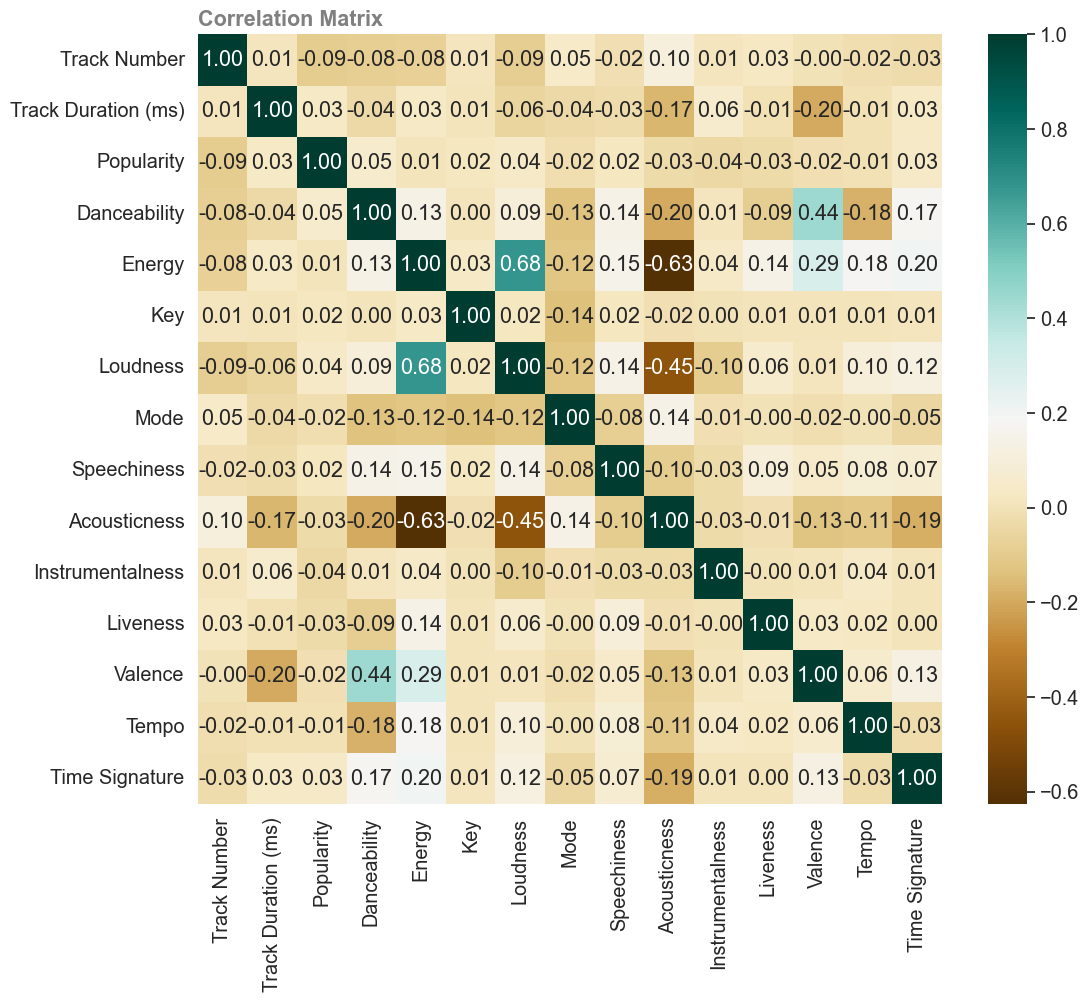

In [41]:
plt.figure(figsize=(12, 10))
sns.heatmap(num_df.corr(), cmap='BrBG', annot=True, fmt='.2f')
plt.title("Correlation Matrix", loc='left', color='gray', fontweight='bold')
plt.show()

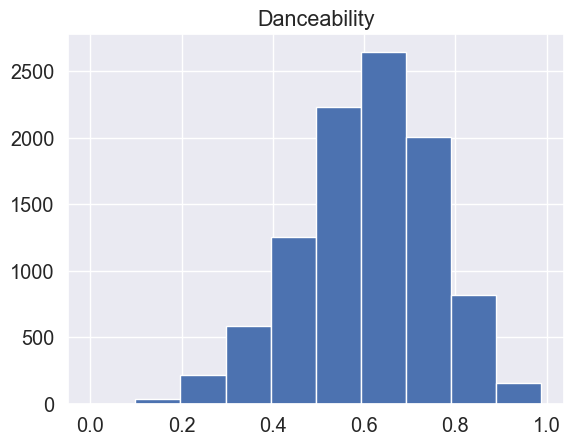

In [42]:
data['Danceability'].hist()
plt.title('Danceability')
plt.show()

In [43]:
stat, p = stats.shapiro(data['Danceability'])
print('stat={0:.3f}, p={0:.3f}'.format(stat, p))

stat=nan, p=nan


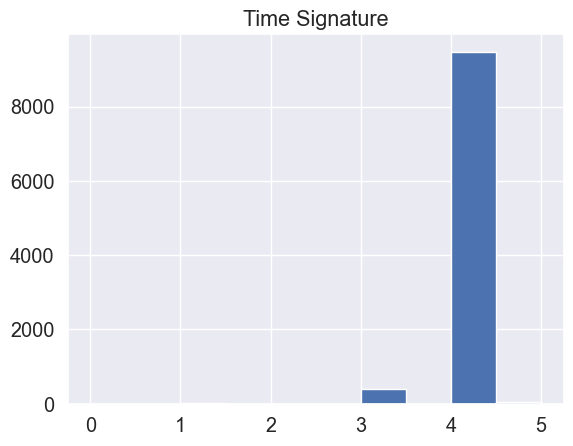

In [44]:
data['Time Signature'].hist()
plt.title('Time Signature')
plt.show()

In [45]:
stat, p = stats.chisquare(data['Time Signature'].value_counts())
print('stat={0:.3f}, p={0:.3f}'.format(stat, p))

stat=35256.627, p=35256.627


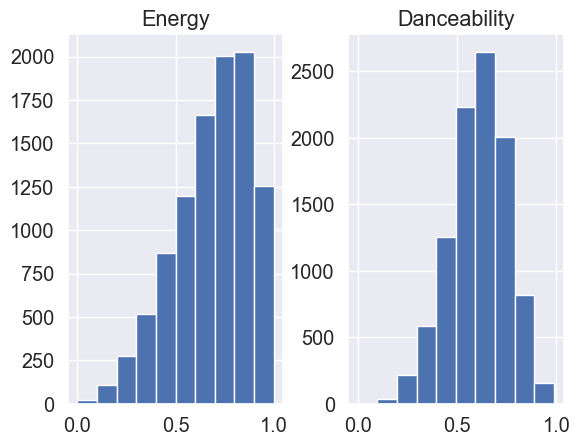

In [46]:
data[['Energy', 'Danceability']].hist()
plt.show()

In [47]:
stat, p = stats.pearsonr(data['Danceability'], data['Energy'])
print('stat={0:.3f}, p={0:.3f}'.format(stat, p))

stat=nan, p=nan


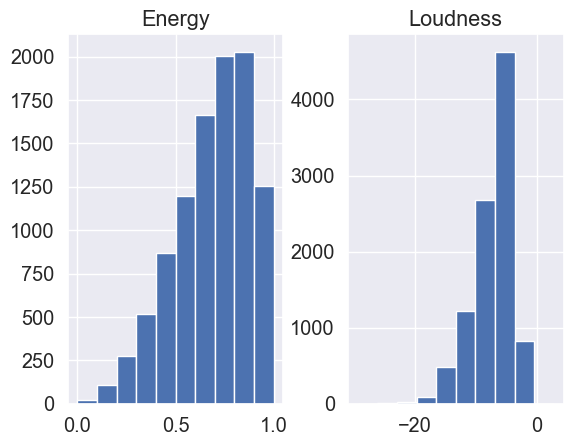

In [48]:
data[['Energy', 'Loudness']].hist()
plt.show()

In [49]:
stat, p = stats.pearsonr(data['Loudness'], data['Energy'])
print('stat={0:.3f}, p={0:.3f}'.format(stat, p))

stat=nan, p=nan


In [51]:
top_correlations = data.corr(numeric_only=True)['Popularity'].sort_values(ascending=False)[0:3]
print(top_correlations)

Popularity      1.000000
Danceability    0.054706
Loudness        0.039446
Name: Popularity, dtype: float64


In [52]:
data[['Energy', 'Danceability']].mean()

Energy          0.684127
Danceability    0.608270
dtype: float64

In [53]:
stat, p = stats.ttest_ind(data['Energy'], data['Danceability'])
print('stat={0:.3f}, p={0:.3f}'.format(stat, p))

stat=nan, p=nan


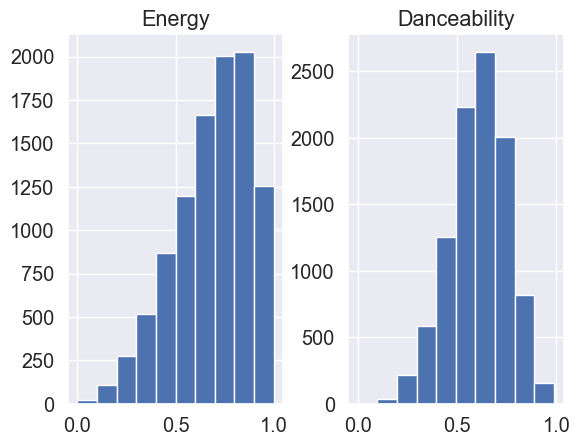

In [54]:
data[['Energy', 'Danceability']].hist()
plt.show()

In [55]:
stat, p = stats.mannwhitneyu(data['Energy'], data['Danceability'])
print('stat={0:.3f}, p={0:.3f}'.format(stat, p))

stat=nan, p=nan
